# Without bias correction, Adam's first step is 3.16× too large

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## Step one, five ways

In [1]:
import numpy as np

rng = np.random.default_rng(0)            # the repo challenge's problem
X = rng.normal(size=(400, 100)) * 10.0
w_true = rng.normal(size=100) * 0.05
y = X @ w_true + 0.00707 * rng.normal(size=400)
print(f"start loss {np.mean(y**2):.2f}, RMS optimum coordinate {np.sqrt(np.mean(w_true**2)):.3f}")
B1, B2 = 0.9, 0.999                       # (m correction, v correction); None = dropped
for name, (cm, cv) in {"both": (B1, B2), "neither": (None, None), "m-hat only": (B1, None),
                       "v-hat only": (None, B2), "m / (1 - b2)": (B2, B2)}.items():
    w, m, v, loss = np.zeros(100), np.zeros(100), np.zeros(100), []
    for t in range(1, 401):
        g = 2 / 400 * X.T @ (X @ w - y)
        m, v = B1 * m + (1 - B1) * g, B2 * v + (1 - B2) * g**2
        mh, vh = m / (1 - cm**t if cm else 1), v / (1 - cv**t if cv else 1)
        w = w - 0.01 * mh / (np.sqrt(vh) + 1e-8)
        loss.append(np.mean((X @ w - y) ** 2))
    print(f"{name:13s} step 1 {loss[0]:9,.1f}  step 100 {loss[99]:.1e}  "
          f"step 200 {loss[199]:.1e}  step 400 {loss[399]:.1e}")

start loss 24.15, RMS optimum coordinate 0.049
both          step 1      16.0  step 100 2.6e-04  step 200 3.8e-05  step 400 3.8e-05
neither       step 1       6.8  step 100 3.7e-04  step 200 3.8e-05  step 400 3.8e-05
m-hat only    step 1     940.6  step 100 4.8e-03  step 200 3.8e-05  step 400 3.8e-05
v-hat only    step 1      23.2  step 100 8.5e-04  step 200 3.8e-05  step 400 3.8e-05
m / (1 - b2)  step 1  11,205.8  step 100 2.4e-02  step 200 3.8e-05  step 400 3.8e-05


## What warmup is compensating for

In [2]:
import numpy as np

b1, b2 = 0.9, 0.999
m1, v1 = 1 - b1, 1 - b2                     # step 1 with g = 1
rows = {"both": (m1 / (1 - b1), v1 / (1 - b2)), "neither": (m1, v1),
        "m-hat only": (m1 / (1 - b1), v1), "v-hat only": (m1, v1 / (1 - b2)),
        "m / (1 - b2)": (m1 / (1 - b2), v1 / (1 - b2))}
for name, (m, v) in rows.items():
    print(f"{name:13s} step/lr = {m / np.sqrt(v):6.2f}")
for t in (100, 1000, 5000):
    print(f"t={t:5d}  1/(1-b2^t) = {1 / (1 - b2**t):5.2f}  "
          f"(1-b1^t)/(1-b2^t) = {(1 - b1**t) / (1 - b2**t):5.2f}")

def n_eff(t, b):
    return (1 + b) * (1 - b**t) / ((1 - b) * (1 + b**t))

for b in (0.999, 0.95):
    print(f"b2={b}: n_eff(10)={n_eff(10, b):.1f}  n_eff(100)={n_eff(100, b):.1f}  "
          f"limit={(1 + b) / (1 - b):.0f}")
    m, v, steps = 1.0, 1.0, []              # steady state at |g| = 1
    for g in [100.0] + [1.0] * 50:          # one rogue batch, G = 100
        m, v = b1 * m + (1 - b1) * g, b * v + (1 - b) * g**2
        steps.append(m / np.sqrt(v))
    print(f"         largest step after the spike = {max(steps):.2f} x normal")

both          step/lr =   1.00
neither       step/lr =   3.16
m-hat only    step/lr =  31.62
v-hat only    step/lr =   0.10
m / (1 - b2)  step/lr = 100.00
t=  100  1/(1-b2^t) = 10.50  (1-b1^t)/(1-b2^t) = 10.50
t= 1000  1/(1-b2^t) =  1.58  (1-b1^t)/(1-b2^t) =  1.58
t= 5000  1/(1-b2^t) =  1.01  (1-b1^t)/(1-b2^t) =  1.01
b2=0.999: n_eff(10)=10.0  n_eff(100)=99.9  limit=1999
         largest step after the spike = 3.29 x normal
b2=0.95: n_eff(10)=9.8  n_eff(100)=38.5  limit=39
         largest step after the spike = 0.49 x normal


In [3]:
rng = np.random.default_rng(0)
b2, v = 0.999, np.zeros(100_000)             # E[g^2] = 1, so the ideal 1/sqrt(v) is 1
for t in range(1, 1001):
    v = b2 * v + (1 - b2) * rng.standard_normal(v.size) ** 2
    if t in (5, 10, 100, 1000):
        r = 1 / np.sqrt(v / (1 - b2**t))
        print(f"t={t:4d}  Monte Carlo {r.mean():.4f}  formula {1 + 0.75 / n_eff(t, b2):.4f}  "
              f"99th percentile {np.percentile(r, 99):.2f}")

t=   5  Monte Carlo 1.1877  formula 1.1500  99th percentile 2.98
t=  10  Monte Carlo 1.0831  formula 1.0750  99th percentile 1.98


t= 100  Monte Carlo 1.0081  formula 1.0075  99th percentile 1.20


t=1000  Monte Carlo 1.0008  formula 1.0008  99th percentile 1.06


## The figure

In [4]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

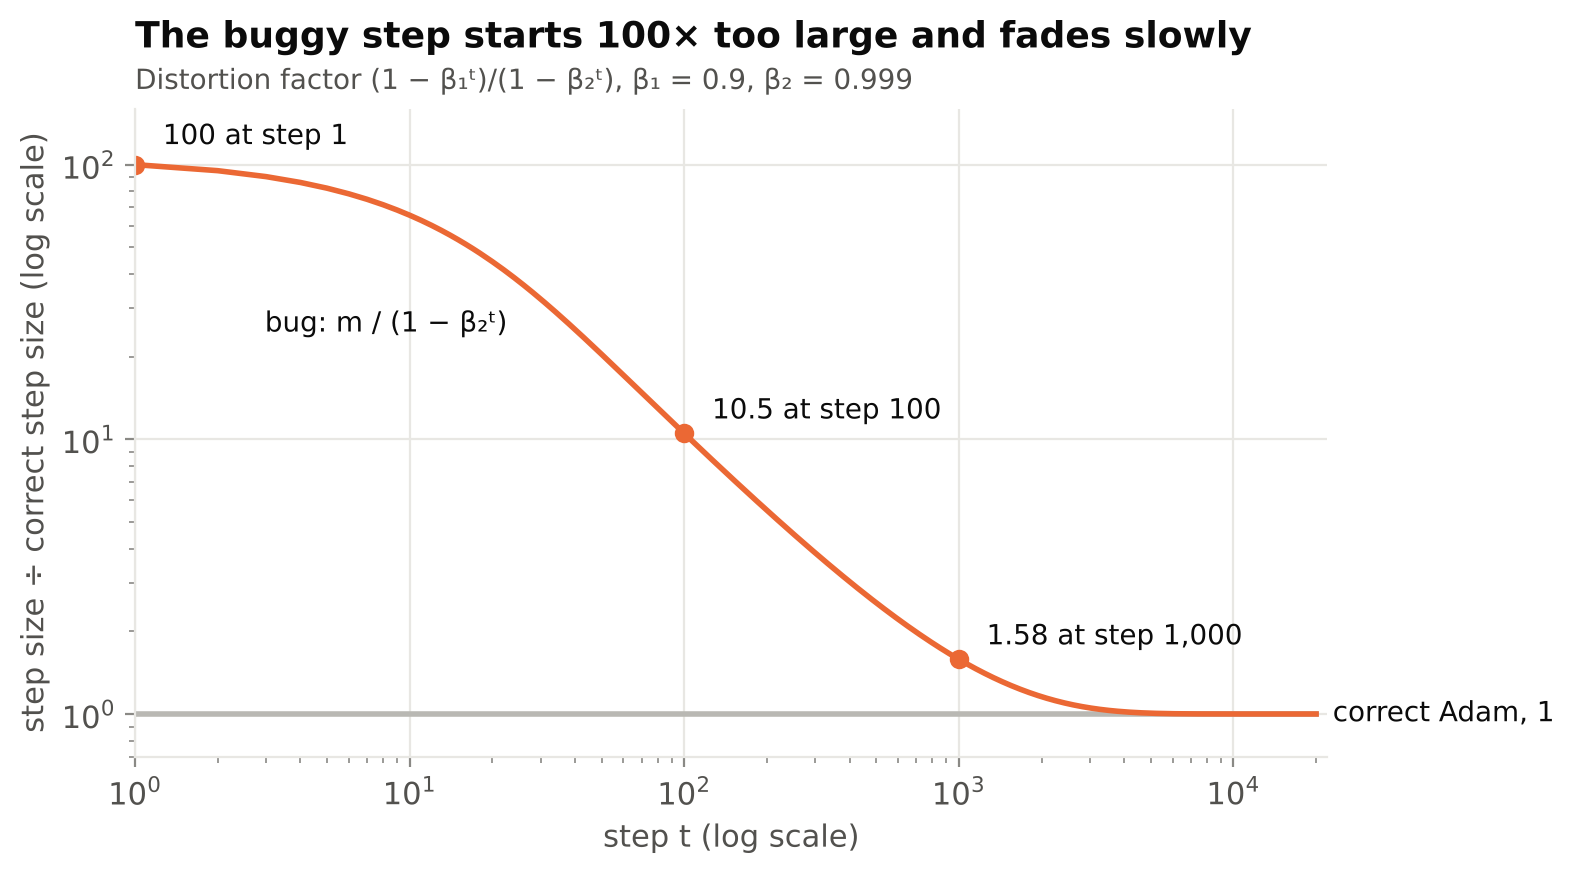

In [5]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    b1, b2 = 0.9, 0.999
    t = np.unique(np.round(np.logspace(0, np.log10(20000), 400)).astype(int))
    dist = (1 - b1**t) / (1 - b2**t)            # bug step / correct step

    f, ax = fig()
    ax.plot(t, np.ones_like(t, dtype=float), color=NEUTRAL, lw=2)
    ax.plot(t, dist, color=S2)
    label_end(ax, t[-1], 1.0, "correct Adam, 1", NEUTRAL, dx=6)
    label_end(ax, t[-1], dist[-1], "", S2)
    for tt, txt, off in ((1, "100 at step 1", (10, 10)),
                         (100, "10.5 at step 100", (10, 8)),
                         (1000, "1.58 at step 1,000", (10, 8))):
        v = (1 - b1**tt) / (1 - b2**tt)
        ax.plot(tt, v, "o", color=S2, ms=6)
        ax.annotate(txt, (tt, v), xytext=off, textcoords="offset points",
                    color=INK, fontsize=10, va="center")
    ax.annotate("bug: m / (1 − β₂ᵗ)", (30, (1 - b1**30) / (1 - b2**30)), xytext=(-12, -4),
                textcoords="offset points", color=INK, fontsize=10, ha="right", va="top")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(1, 20000 * 1.1)
    ax.set_ylim(0.7, 160)
    ax.set_xlabel("step t (log scale)")
    ax.set_ylabel("step size ÷ correct step size (log scale)")
    ax.set_title("The buggy step starts 100× too large and fades slowly")
    subtitle(ax, "Distortion factor (1 − β₁ᵗ)/(1 − β₂ᵗ), β₁ = 0.9, β₂ = 0.999")
    save(f, pathlib.Path(__file__).parent / "02-bias-correction-distortion.png")
    for tt in (1, 100, 1000, 5000): print(tt, (1 - b1**tt) / (1 - b2**tt))
import matplotlib.pyplot as plt
plt.show()